## 泰勒展开与牛顿法

In [1]:
from idlelib import history

import numpy as np
import matplotlib.pyplot as plt
from math import factorial

from fontTools.diff import color
from scipy.stats import alpha

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("success")

success


##  泰勒展开: 用多项式逼近sin()

x = 2,sin(2) = 0.9092974268256817
n=1项:近似=2.0000,误差=1.0907
n=2项:近似=0.6667,误差=0.2426
n=3项:近似=0.9333,误差=0.0240
n=5项:近似=0.9093,误差=0.0001
n=8项:近似=0.9093,误差=0.0000
n=12项:近似=0.9093,误差=0.0000


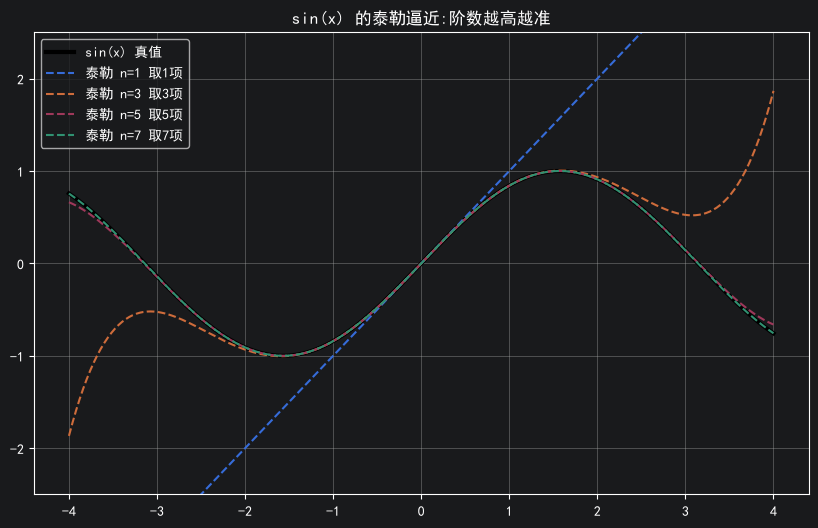

In [2]:
def taylor_sin(x, n):
    s = 0
    for k in range(n):
        s += (-1) ** k * x ** (2 * k + 1) / factorial(2 * k + 1)
    return s


x = np.linspace(-4, 4, 200)

plt.figure(figsize=(10, 6))
plt.plot(x, np.sin(x), 'k-', linewidth=3, label='sin(x) 真值')
for n in [1, 3, 5, 7]:
    plt.plot(x, taylor_sin(x, n), '--', label=f'泰勒 n={n} 取{n}项')
plt.ylim(-2.5, 2.5)
plt.legend()
plt.grid(True)
plt.title('sin(x) 的泰勒逼近:阶数越高越准')

# 验算误差
x_test = 2.0
true_val = np.sin(x_test)
print('x = 2,sin(2) =', true_val)
for n in [1, 2, 3, 5, 8, 12]:
    approx = taylor_sin(x_test, n)
    err = abs(approx - true_val)
    print(f"n={n:d}项:近似={approx:.4f},误差={err:.4f}")

## 麦克劳林展开式 计算e^x

n=1:e^0.1 = 1.0000000
n=2:e^0.1 = 1.1000000
n=3:e^0.1 = 1.1050000
n=5:e^0.1 = 1.1051708
真值 e^0.1 = 1.1051709


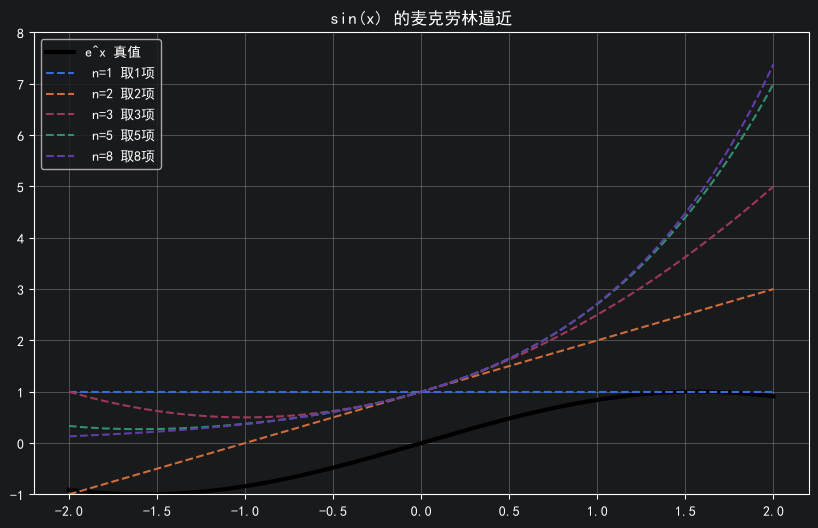

In [3]:
def mkll_exp(x, n):
    return sum(x ** k / factorial(k) for k in range(n))


x = np.linspace(-2, 2, 200)

plt.figure(figsize=(10, 6))
plt.plot(x, np.sin(x), 'k-', linewidth=3, label='e^x 真值')
for n in [1, 2, 3, 5, 8]:
    plt.plot(x, mkll_exp(x, n), '--', label=f' n={n} 取{n}项')
plt.ylim(-1, 8)
plt.legend()
plt.grid(True)
plt.title('sin(x) 的麦克劳林逼近')

# 验算逼近值
for n in [1, 2, 3, 5]:
    print(f'n={n}:e^0.1 = {mkll_exp(0.1, n):.7f}')
print(f"真值 e^0.1 = {np.exp(0.1):.7f}")

## 牛顿法 (求根号2)

真实 sqrt(2) =  1.4142135623730951

第1步:x=1.4166666667,误差=0.002453104293571595
第2步:x=1.4142156863,误差=2.1239014147411694e-06
第3步:x=1.4142135624,误差=1.5947243525715749e-12
第4步:x=1.4142135624,误差=0.0
第5步:x=1.4142135624,误差=2.220446049250313e-16
第6步:x=1.4142135624,误差=0.0
第7步:x=1.4142135624,误差=2.220446049250313e-16
第8步:x=1.4142135624,误差=0.0


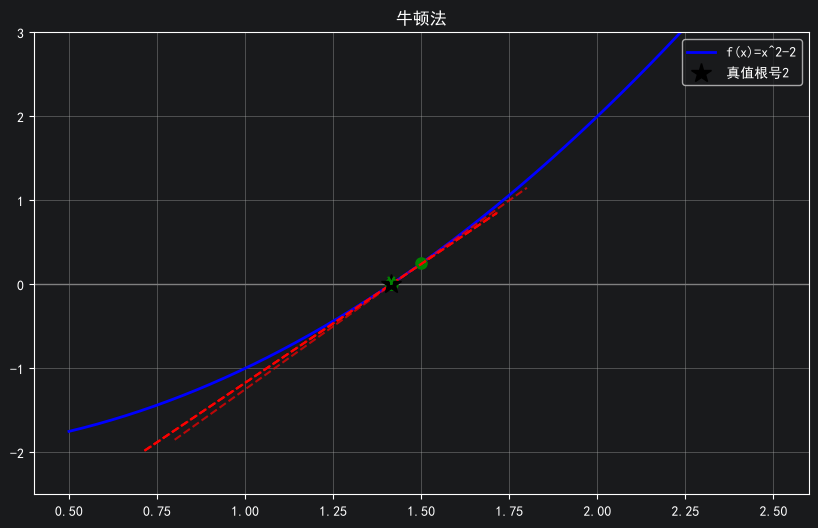

In [4]:
def newton_sqrt2(x0=1.5, iters=8):
    x = x0
    hist = [x]
    for i in range(iters):
        x = x - (x ** 2 - 2) / (2 * x)
        hist.append(x)
        print(f"第{i + 1}步:x={x:.10f},误差={abs(x - 2 ** 0.5)}")
    return x, hist


print('真实 sqrt(2) = ', 2 ** 0.5)
print()
final, hist = newton_sqrt2(1.5, 8)


def f(x):
    return x ** 2 - 2
def fp(x):
    return 2 * x


x = np.linspace(0.5, 2.5, 200)
plt.figure(figsize=(10, 6))
plt.plot(x, f(x), 'b-', linewidth=2, label='f(x)=x^2-2')
plt.axhline(0, color='gray', linewidth=1)

x_cur = 1.5
for i in range(5):
    fx, fpx = f(x_cur), fp(x_cur)
    x_tan = np.linspace(x_cur - 0.7, x_cur + 0.3, 50)
    plt.plot(x_tan, fx + fpx * (x_tan - x_cur), 'r--', alpha=0.7)
    plt.plot(x_cur, fx, 'go', markersize=8)
    x_next = x_cur - fx / fpx
    plt.annotate('', xy=(x_next, 0), xytext=(x_next, f(x_next)), arrowprops=dict(arrowstyle='->', color='green'))
    x_cur = x_next

plt.plot(2 ** 0.5, 0, 'k*', markersize=15, label='真值根号2')
plt.ylim(-2.5, 3)
plt.legend()
plt.grid(True)
plt.title("牛顿法")
plt.show()



## 梯度下降与牛顿法

梯度下降20步:x=2.965412(真值为3)
牛顿法5步:x=3.000000(真值为3)


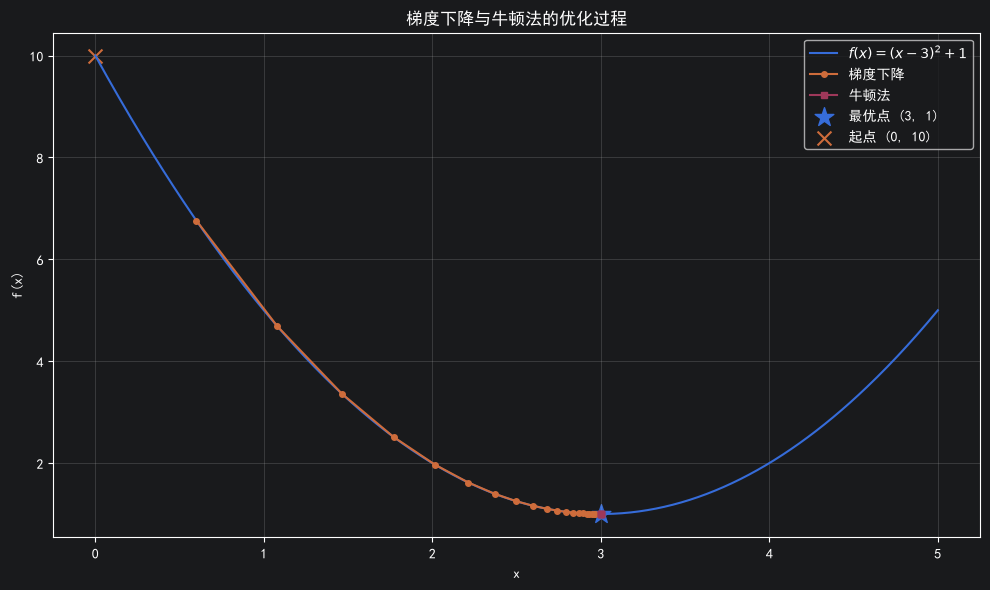

In [5]:
def f_opt(x): return (x - 3) ** 2 + 1


def fp_opt(x): return 2 * (x - 3)


def fpp_opt(x): return 2


x0 = 0.0
x_gd = x0
eta = 0.1
history_tg = []
for i in range(20):
    x_gd = x_gd - eta * fp_opt(x_gd)
    history_tg.append((i, x_gd))
print(f"梯度下降20步:x={x_gd:.6f}(真值为3)")

x_nt = x0
history_nt = []
for i in range(5):
    x_nt = x_nt - fp_opt(x_nt) / fpp_opt(x_nt)
    history_nt.append((i, x_nt))
print(f"牛顿法5步:x={x_nt:.6f}(真值为3)")

# 图像展示
x = np.linspace(0, 5, 500)
y = f_opt(x)
gd_x = [item[1] for item in history_tg]
gd_y = [f_opt(v) for v in gd_x]
nt_x = [item[1] for item in history_nt]
nt_y = [f_opt(v) for v in nt_x]

plt.figure(figsize=(10, 6))

plt.plot(x, y, label=r"$f(x)=(x-3)^2+1$")
plt.plot(gd_x, gd_y, "o-", label="梯度下降", markersize=4)
plt.plot(nt_x, nt_y, "s-", label="牛顿法", markersize=5)

plt.scatter([3], [1], marker="*", s=200, label="最优点 (3, 1)")
plt.scatter([x0], [f_opt(x0)], marker="x", s=100, label="起点 (0, 10)")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("梯度下降与牛顿法的优化过程")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
